In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader

# M4 Çipi için MPS kontrolü
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Harika! Apple M4 GPU (MPS) hızlandırması aktif.")
else:
    device = torch.device("cpu")
    print("Uyarı: MPS bulunamadı, CPU kullanılacak.")

# 1. Veri Setini Yükleme (Öncekiyle aynı)
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes',
            'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
            'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
            'num_shells','num_access_files','num_outbound_cmds','is_host_login',
            'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
            'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
            'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
            'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
            'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
            'dst_host_rerror_rate','dst_host_srv_rerror_rate','attack','level'])

train_df = pd.read_csv('KDDTrain+.txt', names=columns)
test_df = pd.read_csv('KDDTest+.txt', names=columns)

train_df.drop('level', axis=1, inplace=True)
test_df.drop('level', axis=1, inplace=True)

# 2. Etiketleri Düzenleme (Normal = 0, Saldırı = 1)
train_df['attack'] = train_df['attack'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['attack'] = test_df['attack'].apply(lambda x: 0 if x == 'normal' else 1)

y_train = train_df['attack'].values
y_test = test_df['attack'].values
train_df.drop('attack', axis=1, inplace=True)
test_df.drop('attack', axis=1, inplace=True)

# 3. Kategorik Verileri Sayısallaştırma (One-Hot Encoding)
categorical_cols = ['protocol_type', 'service', 'flag']
combined_df = pd.concat([train_df, test_df])
combined_df = pd.get_dummies(combined_df, columns=categorical_cols, dtype=float)

X_train = combined_df.iloc[:len(train_df)]
X_test = combined_df.iloc[len(train_df):]

# 4. Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. PyTorch Tensor'larına Çevirme ve Reshape (1D CNN için)
# PyTorch'ta Conv1D girdi formatı: (Batch_Size, Kanal_Sayısı, Özellik_Sayısı)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print(f"X_train (PyTorch formatı) boyutu: {X_train_tensor.shape}")

# 6. DataLoader Oluşturma (Eğitim sırasında veriyi batch'ler halinde vermek için)
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Harika! Apple M4 GPU (MPS) hızlandırması aktif.
X_train (PyTorch formatı) boyutu: torch.Size([125973, 1, 122])


In [5]:
import torch.nn as nn
import torch.optim as optim

class BaselineCNN1D(nn.Module):
    def __init__(self, num_features):
        super(BaselineCNN1D, self).__init__()
        
        # 1. Evrişim Bloğu
        # in_channels=1 (çünkü verimizi [Batch, 1, 122] yaptık)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        # 2. Evrişim Bloğu
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        
        self.flatten = nn.Flatten()
        
        # Tam Bağlı (Fully Connected) Katmanlar
        # Boyut hesabı: 122 -> pool1(61) -> pool2(30). 30 * 64 (out_channels) = 1920
        flattened_size = (num_features // 2) // 2 * 64 
        
        self.fc1 = nn.Linear(flattened_size, 64)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.5) # Overfitting'i önlemek için %50 unutma
        
        # Çıkış Katmanı (0 veya 1 tahmini yapacağı için tek nöron)
        self.fc2 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.dropout(self.relu3(self.fc1(x)))
        x = self.sigmoid(self.fc2(x))
        return x

# Modeli MPS (M4) cihazına taşıyoruz
num_features = X_train_tensor.shape[2] # 122
cnn_model = BaselineCNN1D(num_features).to(device)

# İkili sınıflandırma için kayıp fonksiyonu (Binary Cross Entropy) ve Optimizatör
criterion = nn.BCELoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

print(cnn_model)

BaselineCNN1D(
  (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu2): ReLU()
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1920, out_features=64, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


Eğitim başlıyor... (M4 işlemcinin hızını görelim!)
Epoch [1/10] | Train Loss: 0.0785, Train Acc: 0.9787 | Val Loss: 0.9769, Val Acc: 0.7681
Epoch [2/10] | Train Loss: 0.0460, Train Acc: 0.9885 | Val Loss: 1.4327, Val Acc: 0.7650
Epoch [3/10] | Train Loss: 0.0416, Train Acc: 0.9910 | Val Loss: 1.5017, Val Acc: 0.7552
Epoch [4/10] | Train Loss: 0.0328, Train Acc: 0.9923 | Val Loss: 1.3525, Val Acc: 0.7543
Epoch [5/10] | Train Loss: 0.0294, Train Acc: 0.9932 | Val Loss: 1.5398, Val Acc: 0.7631
Epoch [6/10] | Train Loss: 0.0270, Train Acc: 0.9941 | Val Loss: 1.6065, Val Acc: 0.7592
Epoch [7/10] | Train Loss: 0.0177, Train Acc: 0.9946 | Val Loss: 1.5846, Val Acc: 0.7849
Epoch [8/10] | Train Loss: 0.0211, Train Acc: 0.9947 | Val Loss: 1.9170, Val Acc: 0.7567
Epoch [9/10] | Train Loss: 0.0151, Train Acc: 0.9949 | Val Loss: 2.0519, Val Acc: 0.7745
Epoch [10/10] | Train Loss: 0.0145, Train Acc: 0.9950 | Val Loss: 2.2635, Val Acc: 0.7741


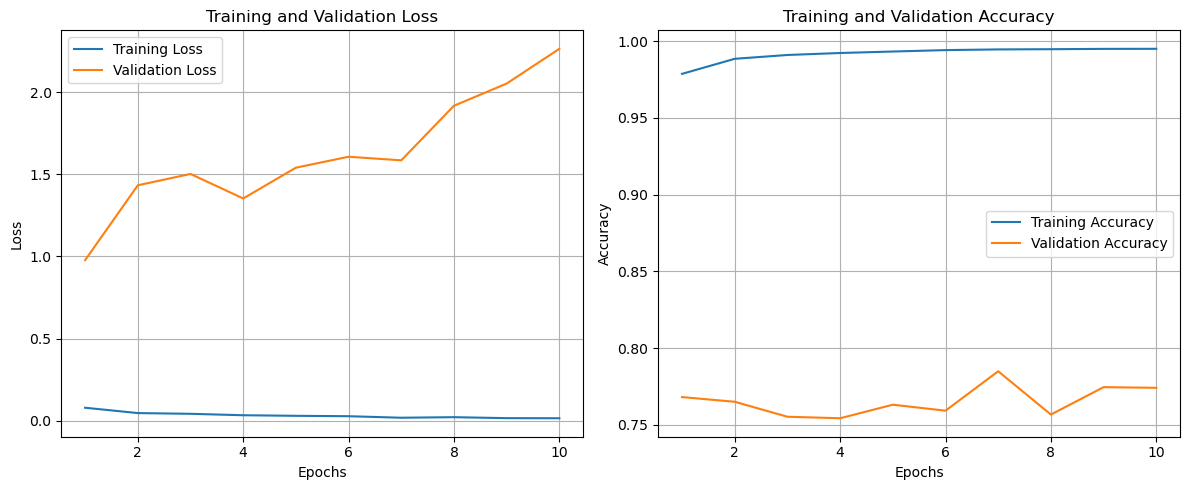

In [6]:
import matplotlib.pyplot as plt

# Eğitim parametreleri
epochs = 10 # Model veriyi 10 kez baştan sona görecek
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print("Eğitim başlıyor... (M4 işlemcinin hızını görelim!)")

for epoch in range(epochs):
    # ---------------- EĞİTİM AŞAMASI ----------------
    cnn_model.train() # Modeli eğitim moduna al (Dropout vb. katmanlar aktif olur)
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()       # 1. Önceki adımdan kalan gradyanları sıfırla
        outputs = cnn_model(inputs) # 2. İleri yayılım (Tahmin yap)
        
        loss = criterion(outputs, labels) # 3. Hatayı (Loss) hesapla
        loss.backward()                   # 4. Geri yayılım (Hataları geriye dağıt)
        optimizer.step()                  # 5. Ağırlıkları güncelle (Öğrenme adımı)
        
        running_loss += loss.item()
        
        # Accuracy (Doğruluk) hesabı
        predicted = (outputs > 0.5).float() # 0.5'ten büyükse 1 (Saldırı), küçükse 0 (Normal)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # ---------------- DOĞRULAMA (VALIDATION) AŞAMASI ----------------
    cnn_model.eval() # Modeli test moduna al (Dropout gibi katmanlar devre dışı kalır)
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # Test sırasında gradyan hesaplamaya gerek yok (hafıza tasarrufu)
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = cnn_model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            predicted = (outputs > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    val_loss = val_loss / len(test_loader)
    val_acc = correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# ---------------- GRAFİKLERİ ÇİZDİRME (RAPOR İÇİN) ----------------
plt.figure(figsize=(12, 5))

# Loss Grafiği
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Grafiği
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, epochs+1), val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
import torch.nn as nn
import torch.optim as optim

# 1. Autoencoder Mimarisi
class TabularAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super(TabularAutoencoder, self).__init__()
        
        # Encoder (Özellik Çıkarımı / Sıkıştırma Kısmı)
        # 122 boyuttan -> 64 -> 32 boyuta düşürüyoruz
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
            nn.ReLU()
        )
        
        # Decoder (Yeniden Oluşturma Kısmı)
        # 32 boyuttan -> 64 -> 122 boyuta geri açıyoruz
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        # [Batch, 1, 122] boyutundaki veriyi düzleştiriyoruz: [Batch, 122]
        x = x.view(x.size(0), -1) 
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
        
    def extract_features(self, x):
        # Ödevin asıl istediği kısım: Sadece Encoder'ı kullan
        x = x.view(x.size(0), -1)
        return self.encoder(x)

# Modeli cihaza (MPS/M4) taşıyalım
input_dim = X_train_tensor.shape[2] # 122
latent_dim = 32 # Sıkıştırılacak boyut (Bu değeri değiştirerek deneyler yapabilirsin)

ae_model = TabularAutoencoder(input_dim, latent_dim).to(device)

# Autoencoder için kayıp fonksiyonu (MSE) ve Optimizatör
ae_criterion = nn.MSELoss()
ae_optimizer = optim.Adam(ae_model.parameters(), lr=0.001)

# 2. Autoencoder Eğitim Döngüsü
ae_epochs = 5 # Özellik çıkarımı için 5 epoch genelde yeterlidir
print("Autoencoder eğitimi başlıyor (Sadece verinin yapısı öğreniliyor)...")

for epoch in range(ae_epochs):
    ae_model.train()
    running_loss = 0.0
    
    for inputs, _ in train_loader: # Dikkat: label'ları (_) kullanmıyoruz!
        inputs = inputs.to(device)
        inputs_flat = inputs.view(inputs.size(0), -1) # Hedefimiz kendisi
        
        ae_optimizer.zero_grad()
        outputs = ae_model(inputs)
        
        # Hata hesaplaması: Girdi ile Çıktı arasındaki fark (MSE)
        loss = ae_criterion(outputs, inputs_flat)
        loss.backward()
        ae_optimizer.step()
        
        running_loss += loss.item()
        
    print(f"AE Epoch [{epoch+1}/{ae_epochs}] | Reconstruction Loss (MSE): {running_loss/len(train_loader):.4f}")

# 3. Özellik Çıkarımı (Feature Extraction)
# Eğitilmiş Encoder'ı kullanarak tüm verimizi 32 boyuta sıkıştırıyoruz
print("\nVeriler Encoder'dan geçiriliyor ve yeni veri seti oluşturuluyor...")
ae_model.eval()

with torch.no_grad():
    # Eğitim setini sıkıştır
    X_train_encoded = ae_model.extract_features(X_train_tensor.to(device))
    # Test setini sıkıştır
    X_test_encoded = ae_model.extract_features(X_test_tensor.to(device))

# Yeni verileri CNN'in beklediği 3 boyutlu formata [Batch, Kanal, Özellik] geri çeviriyoruz
X_train_encoded = X_train_encoded.unsqueeze(1)
X_test_encoded = X_test_encoded.unsqueeze(1)

print(f"Eski Eğitim Verisi Boyutu: {X_train_tensor.shape}")
print(f"Yeni (Sıkıştırılmış) Eğitim Verisi Boyutu: {X_train_encoded.shape}")

Autoencoder eğitimi başlıyor (Sadece verinin yapısı öğreniliyor)...
AE Epoch [1/5] | Reconstruction Loss (MSE): 0.4595
AE Epoch [2/5] | Reconstruction Loss (MSE): 0.2883
AE Epoch [3/5] | Reconstruction Loss (MSE): 0.2750
AE Epoch [4/5] | Reconstruction Loss (MSE): 0.2686
AE Epoch [5/5] | Reconstruction Loss (MSE): 0.2674

Veriler Encoder'dan geçiriliyor ve yeni veri seti oluşturuluyor...
Eski Eğitim Verisi Boyutu: torch.Size([125973, 1, 122])
Yeni (Sıkıştırılmış) Eğitim Verisi Boyutu: torch.Size([125973, 1, 32])


AE-CNN Eğitimi başlıyor...

Epoch [1/10] | Train Loss: 0.1192, Train Acc: 0.9623 | Val Loss: 0.7096, Val Acc: 0.7747
Epoch [2/10] | Train Loss: 0.0498, Train Acc: 0.9829 | Val Loss: 0.7090, Val Acc: 0.7952
Epoch [3/10] | Train Loss: 0.0398, Train Acc: 0.9860 | Val Loss: 0.7255, Val Acc: 0.7861
Epoch [4/10] | Train Loss: 0.0361, Train Acc: 0.9867 | Val Loss: 1.0131, Val Acc: 0.7890
Epoch [5/10] | Train Loss: 0.0341, Train Acc: 0.9875 | Val Loss: 0.8513, Val Acc: 0.7911
Epoch [6/10] | Train Loss: 0.0340, Train Acc: 0.9877 | Val Loss: 1.1257, Val Acc: 0.7846
Epoch [7/10] | Train Loss: 0.0317, Train Acc: 0.9883 | Val Loss: 0.9436, Val Acc: 0.7916
Epoch [8/10] | Train Loss: 0.0309, Train Acc: 0.9884 | Val Loss: 0.9913, Val Acc: 0.7944
Epoch [9/10] | Train Loss: 0.0301, Train Acc: 0.9886 | Val Loss: 1.3839, Val Acc: 0.7887
Epoch [10/10] | Train Loss: 0.0294, Train Acc: 0.9888 | Val Loss: 1.2201, Val Acc: 0.7860

--- AE-CNN MODELİ TEST SONUÇLARI ---
Accuracy  : 0.7860
Precision : 0.9236
Recal

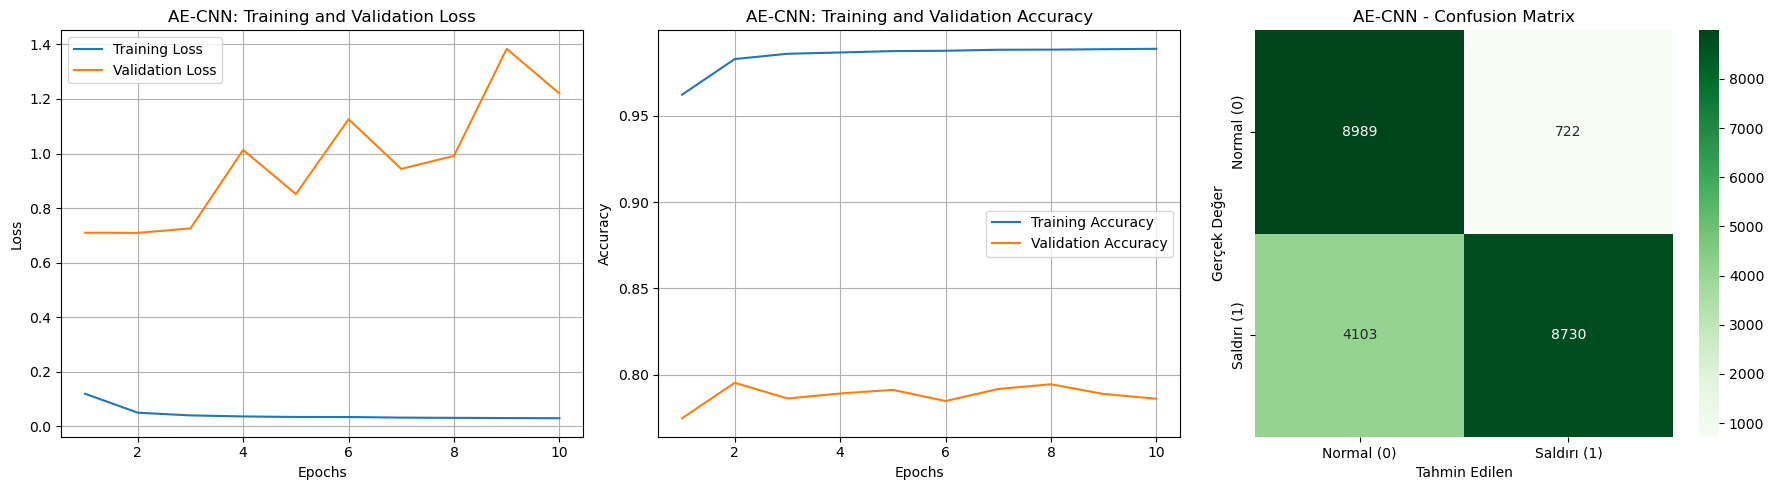

In [8]:
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

# 1. Yeni (Sıkıştırılmış) Veri için DataLoader Hazırlığı
# Tensörleri güvenli bir şekilde CPU'ya alıp Dataset oluşturuyoruz
train_dataset_ae = TensorDataset(X_train_encoded.detach().cpu(), y_train_tensor)
test_dataset_ae = TensorDataset(X_test_encoded.detach().cpu(), y_test_tensor)

train_loader_ae = DataLoader(train_dataset_ae, batch_size=64, shuffle=True)
test_loader_ae = DataLoader(test_dataset_ae, batch_size=64, shuffle=False)

# 2. AE-CNN Sınıflandırma Mimarisi
class AECNN1D(nn.Module):
    def __init__(self):
        super(AECNN1D, self).__init__()
        
        # Girdi boyutu artık 122 değil, 32!
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2) # 32 -> 16
        
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2) # 16 -> 8
        
        self.flatten = nn.Flatten()
        
        # 8 * 32 (out_channels) = 256
        self.fc1 = nn.Linear(256, 32)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.dropout(self.relu3(self.fc1(x)))
        x = self.sigmoid(self.fc2(x))
        return x

# Modeli M4 (MPS) cihazına taşı
aecnn_model = AECNN1D().to(device)
criterion = nn.BCELoss()
optimizer_aecnn = optim.Adam(aecnn_model.parameters(), lr=0.001)

# 3. AE-CNN Eğitim Döngüsü
epochs = 10
train_losses_ae, val_losses_ae = [], []
train_accuracies_ae, val_accuracies_ae = [], []

print("AE-CNN Eğitimi başlıyor...\n")

for epoch in range(epochs):
    # Eğitim Modu
    aecnn_model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader_ae:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer_aecnn.zero_grad()
        outputs = aecnn_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_aecnn.step()
        
        running_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    train_losses_ae.append(running_loss / len(train_loader_ae))
    train_accuracies_ae.append(correct_train / total_train)
    
    # Test (Validation) Modu
    aecnn_model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in test_loader_ae:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = aecnn_model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            predicted = (outputs > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    val_losses_ae.append(val_loss / len(test_loader_ae))
    val_accuracies_ae.append(correct_val / total_val)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_losses_ae[-1]:.4f}, Train Acc: {train_accuracies_ae[-1]:.4f} | Val Loss: {val_losses_ae[-1]:.4f}, Val Acc: {val_accuracies_ae[-1]:.4f}")

# 4. AE-CNN Metrikleri ve Confusion Matrix
all_preds_ae, all_labels_ae = [], []
with torch.no_grad():
    for inputs, labels in test_loader_ae:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = aecnn_model(inputs)
        predicted = (outputs > 0.5).float()
        all_preds_ae.extend(predicted.cpu().numpy())
        all_labels_ae.extend(labels.cpu().numpy())

acc_ae = accuracy_score(all_labels_ae, all_preds_ae)
precision_ae = precision_score(all_labels_ae, all_preds_ae)
recall_ae = recall_score(all_labels_ae, all_preds_ae)
f1_ae = f1_score(all_labels_ae, all_preds_ae)

print("\n--- AE-CNN MODELİ TEST SONUÇLARI ---")
print(f"Accuracy  : {acc_ae:.4f}")
print(f"Precision : {precision_ae:.4f}")
print(f"Recall    : {recall_ae:.4f}")
print(f"F1-Score  : {f1_ae:.4f}")

# 5. Grafikleri Çizdirme
plt.figure(figsize=(18, 5))

# AE-CNN Loss Grafiği
plt.subplot(1, 3, 1)
plt.plot(range(1, epochs+1), train_losses_ae, label='Training Loss')
plt.plot(range(1, epochs+1), val_losses_ae, label='Validation Loss')
plt.title('AE-CNN: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# AE-CNN Accuracy Grafiği
plt.subplot(1, 3, 2)
plt.plot(range(1, epochs+1), train_accuracies_ae, label='Training Accuracy')
plt.plot(range(1, epochs+1), val_accuracies_ae, label='Validation Accuracy')
plt.title('AE-CNN: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# AE-CNN Confusion Matrix
cm_ae = confusion_matrix(all_labels_ae, all_preds_ae)
plt.subplot(1, 3, 3)
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Normal (0)', 'Saldırı (1)'], 
            yticklabels=['Normal (0)', 'Saldırı (1)'])
plt.title('AE-CNN - Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')

plt.tight_layout()
plt.show()

In [10]:
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import numpy as np
import copy
from torch.utils.data import TensorDataset, DataLoader

# ---------------- 1. GELİŞMİŞ AUTOENCODER ----------------
latent_dim = 64 # Opus'un tavsiyesi: Darboğazı genişlettik

class ImprovedAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(ImprovedAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 90),
            nn.ReLU(),
            nn.Linear(90, latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 90),
            nn.ReLU(),
            nn.Linear(90, input_dim)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.decoder(self.encoder(x))
        
    def extract_features(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)

ae_model = ImprovedAutoencoder(input_dim=122, latent_dim=latent_dim).to(device)
ae_optimizer = optim.Adam(ae_model.parameters(), lr=0.001)
ae_criterion = nn.MSELoss()

print("Gelişmiş Autoencoder eğitimi başlıyor...")
ae_epochs = 30 # Opus'un tavsiyesi: Daha uzun eğitim
for epoch in range(ae_epochs):
    ae_model.train()
    running_loss = 0.0
    for inputs, _ in train_loader:
        inputs = inputs.to(device)
        inputs_flat = inputs.view(inputs.size(0), -1)
        ae_optimizer.zero_grad()
        loss = ae_criterion(ae_model(inputs), inputs_flat)
        loss.backward()
        ae_optimizer.step()
        running_loss += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"AE Epoch [{epoch+1}/{ae_epochs}] | MSE: {running_loss/len(train_loader):.4f}")

# Özellikleri çıkartıp yeni veri setini oluşturuyoruz (64 Boyutlu)
ae_model.eval()
with torch.no_grad():
    X_train_encoded = ae_model.extract_features(X_train_tensor.to(device)).unsqueeze(1)
    X_test_encoded = ae_model.extract_features(X_test_tensor.to(device)).unsqueeze(1)

train_loader_ae = DataLoader(TensorDataset(X_train_encoded.detach().cpu(), y_train_tensor), batch_size=64, shuffle=True)
test_loader_ae = DataLoader(TensorDataset(X_test_encoded.detach().cpu(), y_test_tensor), batch_size=64, shuffle=False)

# ---------------- 2. GELİŞMİŞ AE-CNN MİMARİSİ ----------------
class ImprovedAECNN1D(nn.Module):
    def __init__(self):
        super(ImprovedAECNN1D, self).__init__()
        # Karmaşıklığı azalttık, Batch Normalization ekledik
        self.conv1 = nn.Conv1d(1, 8, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(8)
        self.pool1 = nn.MaxPool1d(2) # 64 -> 32
        
        self.conv2 = nn.Conv1d(8, 16, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(16)
        self.pool2 = nn.MaxPool1d(2) # 32 -> 16
        
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(16 * 16, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5) # Dropout artırıldı
        self.fc2 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.sigmoid(self.fc2(x))

aecnn_model = ImprovedAECNN1D().to(device)

# Weight Decay (L2 Regularization) eklendi
optimizer = optim.Adam(aecnn_model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.BCELoss()

# Öğrenme Hızı Planlayıcı (Learning Rate Scheduler)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

# ---------------- 3. EARLY STOPPING İLE EĞİTİM DÖNGÜSÜ ----------------
epochs = 30
early_stop_patience = 5
best_val_loss = float('inf')
patience_counter = 0
best_model_weights = None

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print("\nGelişmiş AE-CNN Eğitimi başlıyor (Early Stopping Aktif)...")

for epoch in range(epochs):
    aecnn_model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader_ae:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = aecnn_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_loss = running_loss / len(train_loader_ae)
    train_acc = correct / total
    
    aecnn_model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader_ae:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = aecnn_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            predicted = (outputs > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    val_loss = val_loss / len(test_loader_ae)
    val_acc = correct_val / total_val
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    # Scheduler'ı Validation Loss'a göre güncelle
    scheduler.step(val_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    
    # Early Stopping Kontrolü
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_weights = copy.deepcopy(aecnn_model.state_dict()) # En iyi anı kaydet
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"\n[!] Early Stopping tetiklendi! Model {epoch+1}. epoch'ta overfitting'e gitmeden durduruldu.")
            break

# Eğitimi kestiysek, ağırlıkları en iyi olduğu ana geri sarıyoruz
if best_model_weights:
    aecnn_model.load_state_dict(best_model_weights)
    print("En iyi validation loss değerine sahip model ağırlıkları yüklendi.")

# Metrikleri hesaplamak için aynı plot kodlarını (Önceki mesajdaki) kullanabilirsin.

Gelişmiş Autoencoder eğitimi başlıyor...
AE Epoch [5/30] | MSE: 0.1387
AE Epoch [10/30] | MSE: 0.1213
AE Epoch [15/30] | MSE: 0.1120
AE Epoch [20/30] | MSE: 0.1107
AE Epoch [25/30] | MSE: 0.1064
AE Epoch [30/30] | MSE: 0.1017

Gelişmiş AE-CNN Eğitimi başlıyor (Early Stopping Aktif)...
Epoch [1/30] | Train Loss: 0.0966, Acc: 0.9686 | Val Loss: 0.7885, Acc: 0.7983
Epoch [2/30] | Train Loss: 0.0444, Acc: 0.9848 | Val Loss: 0.9900, Acc: 0.7884
Epoch [3/30] | Train Loss: 0.0362, Acc: 0.9871 | Val Loss: 1.1610, Acc: 0.7847
Epoch [4/30] | Train Loss: 0.0339, Acc: 0.9879 | Val Loss: 1.1218, Acc: 0.7773
Epoch [5/30] | Train Loss: 0.0287, Acc: 0.9895 | Val Loss: 1.3048, Acc: 0.7837
Epoch [6/30] | Train Loss: 0.0288, Acc: 0.9903 | Val Loss: 1.3018, Acc: 0.7873

[!] Early Stopping tetiklendi! Model 6. epoch'ta overfitting'e gitmeden durduruldu.
En iyi validation loss değerine sahip model ağırlıkları yüklendi.



🚀 --- GELİŞMİŞ AE-CNN FİNAL SONUÇLARI ---
Accuracy  : 0.7983
Precision : 0.9232
Recall    : 0.7044
F1-Score  : 0.7991


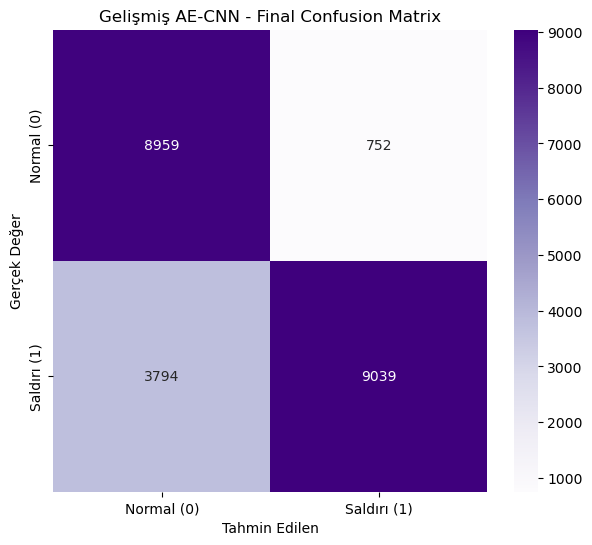

In [11]:
# Modeli değerlendirme moduna alıp en iyi ağırlıklarla test ediyoruz
aecnn_model.eval()
all_preds_final, all_labels_final = [], []

with torch.no_grad():
    for inputs, labels in test_loader_ae:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = aecnn_model(inputs)
        predicted = (outputs > 0.5).float()
        all_preds_final.extend(predicted.cpu().numpy())
        all_labels_final.extend(labels.cpu().numpy())

# Metriklerin Hesaplanması
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

final_acc = accuracy_score(all_labels_final, all_preds_final)
final_prec = precision_score(all_labels_final, all_preds_final)
final_rec = recall_score(all_labels_final, all_preds_final)
final_f1 = f1_score(all_labels_final, all_preds_final)

print("\n🚀 --- GELİŞMİŞ AE-CNN FİNAL SONUÇLARI ---")
print(f"Accuracy  : {final_acc:.4f}")
print(f"Precision : {final_prec:.4f}")
print(f"Recall    : {final_rec:.4f}")
print(f"F1-Score  : {final_f1:.4f}")

# Confusion Matrix Isı Haritası
cm_final = confusion_matrix(all_labels_final, all_preds_final)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Normal (0)', 'Saldırı (1)'], 
            yticklabels=['Normal (0)', 'Saldırı (1)'])
plt.title('Gelişmiş AE-CNN - Final Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.show()